# Self-Supervised Pre-training vs Supervised Learning on Satellite Imagery
### EuroSAT Benchmark — ResNet-18 | SimCLR | DINO | MAE

## How to Run This Notebook

This notebook is designed to be **resumable at any point** — after a disconnection, after pre-training, or after fine-tuning. All checkpoints and results are saved to Google Drive automatically.

---

### First time running (fresh start)
1. Run **all cells top to bottom** using `Runtime → Run all`
2. When prompted, authenticate Google Drive
3. In the **Pre-training control cell**, set `RUN_PRETRAINING = True`
4. Pre-training takes approximately 7/8 hours on T4 GPU.

---

###  Resuming after a disconnection mid pre-training
1. Run **all cells top to bottom** — `Runtime → Run all`
2. Authenticate Google Drive when prompted
3. In the **Pre-training control cell**, set `RUN_PRETRAINING = True`
4. Each pre-training function will **automatically resume** from the last saved checkpoint — no epochs will be repeated

---

### Pre-training already done — running fine-tuning and evaluation
1. Run **all cells top to bottom** — `Runtime → Run all`
2. Authenticate Google Drive when prompted
3. In the **Pre-training control cell**, leave `RUN_PRETRAINING = False`
4. Encoders will be loaded from Drive and fine-tuning will run immediately

---

### Fine-tuning already done — re-running evaluation/visualizations only
1. Run **all cells top to bottom** — `Runtime → Run all`
2. In the **Pre-training control cell**, leave `RUN_PRETRAINING = False`
3. The supervised baseline and fine-tuning cells will **automatically reload from saved CSVs** if results already exist on Drive — no retraining needed
4. Visualization and summary cells will run using the reloaded dataframes

---

### 📁 What is saved to Google Drive
| File | Location |
|------|----------|
| Pre-training checkpoints (every 10 epochs) | `ssl_satellite/checkpoints/` |
| Final encoder weights | `ssl_satellite/checkpoints/*_encoder_final.pth` |
| Supervised results CSV | `ssl_satellite/results/supervised_results.csv` |
| Fine-tuning results CSVs | `ssl_satellite/results/*_results.csv` |
| Figures (PNG) | `ssl_satellite/results/fig*.png` |

---
> **Tip:** If Drive mount fails, see the troubleshooting note in the Environment Setup cell.

## 1. Environment Setup

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm.auto import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
import torchvision.transforms as T
from torchvision.datasets import EuroSAT
from torchvision.models import resnet18

from sklearn.metrics import f1_score, classification_report, accuracy_score

warnings.filterwarnings('ignore')

# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')

# ── Switching beetween RGB / multispectral ───────────────────────────────────
MODE = "rgb" # you can swap rgb for multispectral if you wish

# ── SSL methods ───────────────────────────────────────────────────────────────
SSL_METHODS = ["moco", "dino"]

# ── Labeling fractions ────────────────────────────────────────────────────────
LABEL_FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]

# ── Training Flags ────────────────────────────────────────────────────────────
SUPERVISED_RUN = True
PRETRAIN_RUN = True
FINETUNE_RUN = True
EVAL_RUN = True

# ── Modeling and Training Parameters ──────────────────────────────────────────
NUM_CLASSES  = 10
IMG_SIZE     = 224
BATCH_SIZE   = 256
NUM_WORKERS  = 4
PRETRAIN_EPOCHS = 100
FINETUNE_EPOCHS = 10

# ── Channels ────────────────────────────────────────────────────────────-----
IN_CHANNELS = 3 if MODE == "rgb" else 13

# ── Constants ─────────────────────────────────────────────────────────────────
DATA_ROOT   = './data'
CKPT_DIR    = '/content/drive/MyDrive/ssl_satellite/checkpoints'
RESULTS_DIR = '/content/drive/MyDrive/ssl_satellite/results'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(f"{CKPT_DIR}/supervised", exist_ok=True)
os.makedirs(f"{CKPT_DIR}/moco", exist_ok=True)
os.makedirs(f"{CKPT_DIR}/dino", exist_ok=True)


print(f"Mode: {MODE} | Channels: {IN_CHANNELS}")
print(f"Checkpoints: {CKPT_DIR}")
print(f"Results: {RESULTS_DIR}")

# ── EuroSAT ─────────────────────────────────────────────────────────────────
EUROSAT_CLASSES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]

# ── EuroSAT normalization ────────────────────────────────────────────────────
EUROSAT_MEAN_RGB = [0.3444, 0.3803, 0.4078]
EUROSAT_STD_RGB = [0.2025, 0.1365, 0.1148]

# ── Multispectral normalization ──────────────────────────────────────────────
EUROSAT_MEAN_MS = [0.5] * 13
EUROSAT_STD_MS = [0.2] * 13

# ── Transformations ───────────────────────────────────────────────────────────
def get_supervised_transform():
  if MODE == "rgb":
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(EUROSAT_MEAN_RGB, EUROSAT_STD_RGB),
    ])
  else:
      return T.Compose([
          T.Resize((IMG_SIZE, IMG_SIZE)),
          T.RandomHorizontalFlip(),
          T.ToTensor(),
          T.Normalize(EUROSAT_MEAN_MS, EUROSAT_STD_MS),
      ])
def get_ssl_transform():
  if MODE == "rgb":
    return T.Compose([
        T.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
        T.RandomHorizontalFlip(),
        T.ColorJitter(0.4, 0.4, 0.4, 0.1),
        T.ToTensor(),
        T.Normalize(EUROSAT_MEAN_RGB, EUROSAT_STD_RGB),
    ])
  else:
      return T.Compose([
          T.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
          T.RandomHorizontalFlip(),
          T.ToTensor(),
          T.Normalize(EUROSAT_MEAN_MS, EUROSAT_STD_MS),
      ])

# ── Building Model ─────────────────────────────────────────────────────────────────
def resnet18_build(num_classes=NUM_CLASSES, in_channels=IN_CHANNELS):
  model = resnet18(weights=None)
  # Supporting 13 channels
  if in_channels != 3:
    old_conv = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels,
        old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  return model

Mounted at /content/drive
Device: cuda
PyTorch: 2.10.0+cu128
torchvision: 0.25.0+cu128
Mode: rgb | Channels: 3
Checkpoints: /content/drive/MyDrive/ssl_satellite/checkpoints
Results: /content/drive/MyDrive/ssl_satellite/results


### Checkpoint Utilities

In [ ]:
import os
import re
from pathlib import Path

# ── Checkpoint utilities ──────────────────────────────────────────────────────
def get_checkpoint_path(method, filename):
  """Create a checkpoint path."""
  method_dir = os.path.join(CKPT_DIR, method)
  os.makedirs(method_dir, exist_ok=True)
  return os.path.join(method_dir, filename)

def save_checkpoint(state, method, filename):
    """
    Save a checkpoint to Google Drive.
    Example:
    checkpoints/rgb/moco/moco_epoch10.pth
    """
    path = get_checkpoint_path(method, filename)
    torch.save(state, path)
    print(f'  ✓ Checkpoint saved → {path}')

def find_latest_checkpoint(method, prefix):
    """
    Find the latest checkpoint for a given method and prefix.
    """
    method_dir = os.path.join(CKPT_DIR, method)
    if not os.path.exists(method_dir):
        return None
    ckpts = sorted(
        Path(method_dir).glob(f'{prefix}_epoch*.pth'),
        key=lambda p: int(re.search(r'epoch(\d+)', p.stem).group(1))
    )
    return ckpts[-1] if ckpts else None

def load_checkpoint(path, model, optimizer=None, scheduler=None):
  """
  Load the checkpoint.
  """
  ckpt = torch.load(path, map_location=DEVICE)
  model.load_state_dict(ckpt['model_state_dict'])
  if optimizer and 'optimizer_state_dict' in ckpt:
      optimizer.load_state_dict(ckpt['optimizer_state_dict'])
  if scheduler and 'scheduler_state_dict' in ckpt:
      scheduler.load_state_dict(ckpt['scheduler_state_dict'])

  epoch = ckpt.get("epoch", "unknown")
  print(f'  ✓ Resumed from epoch {ckpt["epoch"]} ({path.name})')
  return ckpt

def checkpoint_exists(method, prefix):
  """Running a quick check if a checkpoint exists."""
  method_dir = os.path.join(CKPT_DIR, method)
  if not os.path.exists(method_dir):
    return False
  return len(list(Path(method_dir).glob(f'{prefix}_epoch*.pth'))) > 0

print("✓ Checkpoint utilities ready.")

✓ Checkpoint utilities ready.


## 2. Dataset Loading & Preprocessing

In [ ]:
# ── Transforms ────────────────────────────────────────────────────────────────

# ── Supervised Learning Transforms ────────────────────────────────────────────
def get_train_transform():
  if MODE == "rgb":
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),
        T.RandomRotation(90),
        T.ColorJitter(0.2, 0.2, 0.1, 0.05),
        T.ToTensor(),
        T.Normalize(EUROSAT_MEAN_RGB, EUROSAT_STD_RGB),
    ])
  else:
      return T.Compose([
          T.Resize((IMG_SIZE, IMG_SIZE)),
          T.RandomHorizontalFlip(),
          T.RandomVerticalFlip(),
          T.RandomRotation(90),
          T.ToTensor(),
          T.Normalize(EUROSAT_MEAN_MS, EUROSAT_STD_MS),
      ])
def get_eval_transform():
  if MODE == "rgb":
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(EUROSAT_MEAN_RGB, EUROSAT_STD_RGB),
    ])
  else:
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(EUROSAT_MEAN_MS, EUROSAT_STD_MS),
      ])
# ── SSL Transforms ────────────────────────────────────────────────────────────
def get_ssl_transform():
  if MODE == "rgb":
    return T.Compose([
        T.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
        T.RandomHorizontalFlip(),
        T.ColorJitter(0.4, 0.4, 0.4, 0.1),
        T.ToTensor(),
        T.Normalize(EUROSAT_MEAN_RGB, EUROSAT_STD_RGB),
    ])
  else:
    return T.Compose([
        T.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(EUROSAT_MEAN_MS, EUROSAT_STD_MS),
    ])
# ── MoCo wrapper (two-views) ──────────────────────────────────────────────────
class TwoViewTransforms:
  def __init__(self, base_transform):
      self.base_transform = base_transform

  def __call__(self, x):
      return self.base_transform(x), self.base_transform(x)

# ── Load the Dataset ──────────────────────────────────────────────────────────
eval_transform = get_eval_transform()
full_dataset = EuroSAT(root=DATA_ROOT, download=True, transform=eval_transform)

print(f'Total EuroSAT images: {len(full_dataset)}')
print(f'Classes: {full_dataset.classes}')


# ── Download & split ──────────────────────────────────────────────────────────
def stratified_split(dataset, train_frac=0.70, val_frac=0.15, seed=SEED):
    """Return (train_idx, val_idx, test_idx) with stratification."""
    rng = np.random.default_rng(seed)
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    train_idx, val_idx, test_idx = [], [], []
    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0]
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(n * train_frac)
        n_val   = int(n * val_frac)
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(full_dataset)
print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

# ── Dataset creation ──────────────────────────────────────────────────────────
train_transform = get_train_transform()

train_dataset_full = EuroSAT(root=DATA_ROOT, transform=train_transform)
val_dataset  = Subset(EuroSAT(root=DATA_ROOT, transform=eval_transform), val_idx)
test_dataset = Subset(EuroSAT(root=DATA_ROOT, transform=eval_transform), test_idx)

val_loader   = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


# ── Stratfied labeled subset ──────────────────────────────────────────────────

def get_labeled_subset(full_train_idx, fraction, seed=SEED):
    """Stratified subset of training data at given label fraction."""
    rng = np.random.default_rng(seed)
    base_ds = EuroSAT(root=DATA_ROOT, transform=train_transform)
    labels  = np.array([base_ds[i][1] for i in full_train_idx])
    selected = []
    for cls in np.unique(labels):
        cls_local = np.where(labels == cls)[0]
        n = max(1, int(len(cls_local) * fraction))
        chosen = rng.choice(cls_local, n, replace=False)
        selected.extend([full_train_idx[i] for i in chosen])
    return Subset(base_ds, selected)

# ── Subset sizing (debug) ─────────────────────────────────────────────────────

print('\nLabeled subset sizes per fraction:')
for frac in LABEL_FRACTIONS:
    sub = get_labeled_subset(train_idx, frac)
    print(f'  {int(frac*100):3d}%  →  {len(sub):5d} images')

100%|██████████| 94.3M/94.3M [00:00<00:00, 279MB/s]


Total EuroSAT images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train: 18900 | Val: 4050 | Test: 4050

Labeled subset sizes per fraction:
    1%  →    187 images
    5%  →    943 images
   10%  →   1890 images
   25%  →   4723 images
   50%  →   9450 images
  100%  →  18900 images


### Optional: Visualize Sample Patches
*(Safe to skip — does not affect training)*

  ✓ Saved visualization → /content/drive/MyDrive/ssl_satellite/results/eurosat_samples_rgb.png


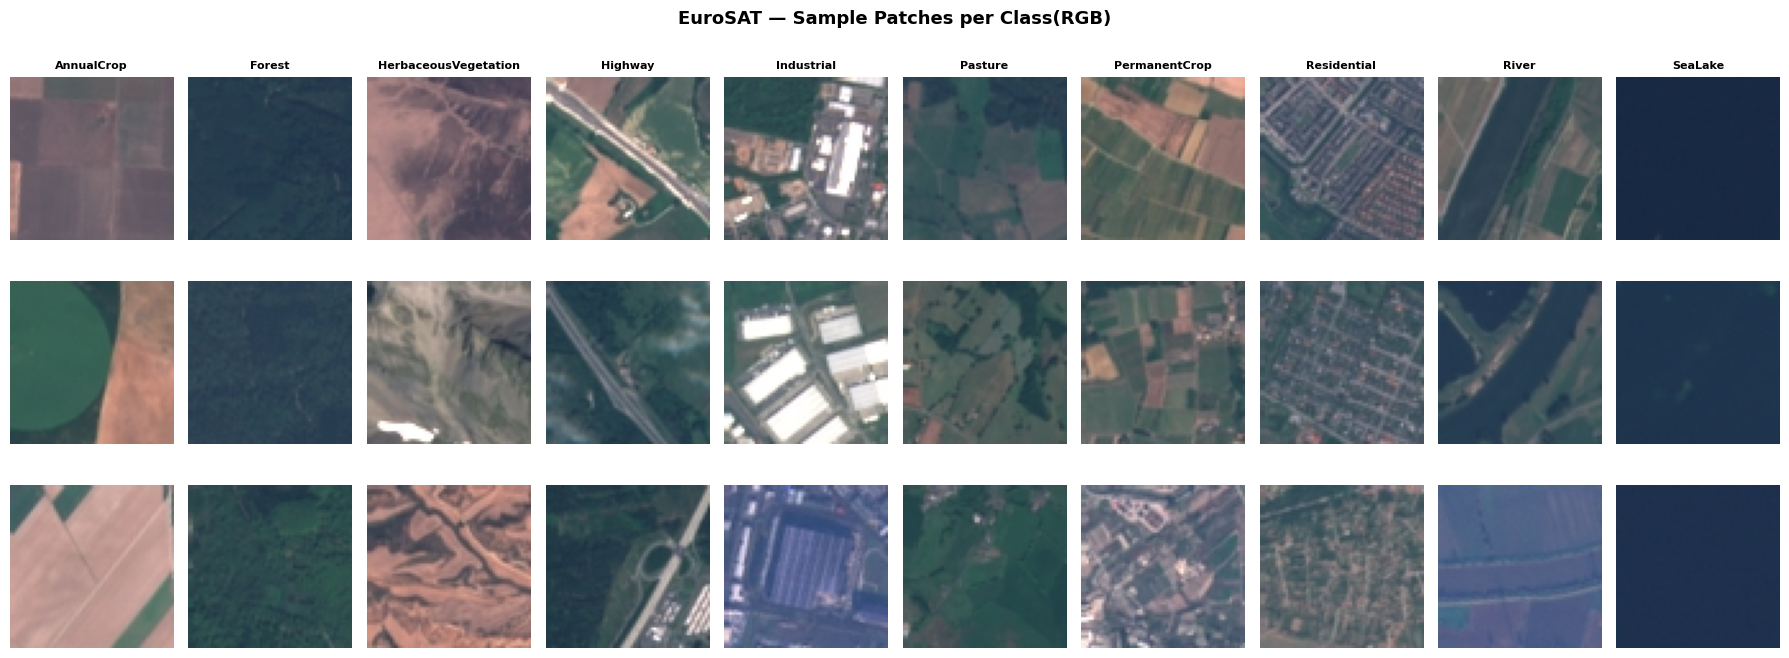

In [ ]:
# ── Visualize sample patches ──────────────────────────────────────────────────
def imshow_grid(n_per_class=3, figsize=(18, 7)):
  """
  Visualize the sample patches by class.
  Works when using RGB and multispectal (first three bands).
  """
  if MODE == "rgb":
    visual_transform = T.Compose([
        T.Resize((64, 64)),
        T.ToTensor()
    ])
  else:
    visual_transform = T.Compose([
        T.Resize((64, 64)),
        T.ToTensor()
    ])
  base = EuroSAT(root=DATA_ROOT, transform=T.Compose([T.Resize((64, 64)), T.ToTensor()]))
  by_class = {c: [] for c in range(NUM_CLASSES)}
  for img, label in base:
      if len(by_class[label]) < n_per_class:
          by_class[label].append(img)
      if all(len(v) >= n_per_class for v in by_class.values()):
          break
  fig, axes = plt.subplots(n_per_class, NUM_CLASSES, figsize=figsize)
  for cls_idx, cls_name in enumerate(EUROSAT_CLASSES):
      for row, img in enumerate(by_class[cls_idx]):
          ax = axes[row, cls_idx]
          if MODE == "rgb":
            ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
          else:
            img_vis = img[:3, :, :]
            img_vis = (img_vs - img_vis.min()) / (img_vis.max() - img_vis.min() + 1e-6)
            ax.imshow(img_vis.permute(1, 2, 0))
          ax.axis('off')
          if row == 0:
              ax.set_title(cls_name, fontsize=8, fontweight='bold')
  plt.suptitle(f'EuroSAT — Sample Patches per Class({MODE.upper()})', fontsize=13, fontweight='bold')
  plt.tight_layout()
  save_path = f'{RESULTS_DIR}/eurosat_samples_{MODE}.png'
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
  print(f'  ✓ Saved visualization → {save_path}')
  plt.show()

imshow_grid()

## 3. Supervised Baseline — ResNet-18 from Scratch

In [ ]:
# ── Evaluation utility ────────────────────────────────────────────────────────
def evaluate(model, loader, device=DEVICE):
    """Return (accuracy, macro_f1, per_class_f1, all_preds, all_labels)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc        = accuracy_score(all_labels, all_preds)
    macro_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    per_cls_f1 = f1_score(all_labels, all_preds, average=None,    zero_division=0)
    return acc, macro_f1, per_cls_f1, all_preds, all_labels


# ── Supervised training ───────────────────────────────────────────────────────
def train_supervised(
    train_loader, val_loader, test_loader,
    num_classes=NUM_CLASSES,
    epochs=100,
    lr=0.1,
    weight_decay=1e-4,
    label_smoothing=0.1,
    patience=15,
    method="supervised",
    prefix='supervised',
    device=DEVICE
):
    model = resnet18_build(num_classes=num_classes, in_channels=IN_CHANNELS)
    model = model.to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr,
                                 momentum=0.9, weight_decay=weight_decay,
                                 nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    # ── Resume if checkpoint exists ───────────────────────────────────────────
    start_epoch  = 1
    best_val_acc = 0.0
    best_state   = None
    wait         = 0

    latest = find_latest_checkpoint(method, prefix)
    if latest:
        ckpt         = load_checkpoint(latest, model, optimizer, scheduler)
        start_epoch  = ckpt['epoch'] + 1
        best_val_acc = ckpt.get('best_val_acc', 0.0)
        best_state   = deepcopy(model.state_dict())

    history = []
    for epoch in range(start_epoch, epochs + 1):
        model.train()
        train_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()

        val_acc, val_f1, _, _, _ = evaluate(model, val_loader, device)
        history.append({'epoch': epoch, 'loss': train_loss, 'val_acc': val_acc})
        print(f'  Epoch {epoch:3d}/{epochs}  loss: {train_loss:.3f}  val_acc: {val_acc*100:.2f}%')

        # ── Save every 10 epochs ──────────────────────────────────────────────
        if epoch % 10 == 0:
            # Generate the correct full path using get_checkpoint_path
            full_ckpt_path = get_checkpoint_path(method, f'{prefix}_epoch{epoch}.pth')
            save_checkpoint({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_acc': best_val_acc,
            }, method, f'{prefix}_epoch{epoch}.pth')

        # ── Early stopping ────────────────────────────────────────────────────


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = deepcopy(model.state_dict())
            wait         = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    test_acc, macro_f1, per_cls_f1, preds, labels = evaluate(model, test_loader, device)
    return test_acc, macro_f1, per_cls_f1, history, model


# ── Run supervised baseline or reload from CSV ───────────────────────────────
sup_csv = f'{RESULTS_DIR}/supervised_results.csv'
if os.path.exists(sup_csv):
    sup_df = pd.read_csv(sup_csv)
    print(f'✓ Loaded existing supervised results from Drive ({len(sup_df)} rows)')
else:
    print('=' * 60)
    print('SUPERVISED BASELINE — ResNet-18 ({MODE.upper()})')
    print('=' * 60)
    supervised_results = []
    for frac in LABEL_FRACTIONS:
        set_seed()
        subset = get_labeled_subset(train_idx, frac)
        loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True)
        print(f'\nFraction {int(frac*100):3d}%  ({len(subset)} images)')

        acc, macro_f1, per_cls_f1, history, _ = train_supervised(
            loader, val_loader, test_loader,
            epochs=100, patience=15,
            method="supervised",
            prefix=f'supervised_frac{int(frac*100)}'
        )
        row = {
            'mode': MODE,
            'method': 'Supervised', 'fraction': frac,
            'accuracy': round(acc, 4), 'macro_f1': round(macro_f1, 4)
        }
        for i, cls in enumerate(EUROSAT_CLASSES):
            row[f'f1_{cls}'] = round(float(per_cls_f1[i]), 4)
        supervised_results.append(row)
        print(f'  → Test Acc: {acc*100:.2f}%  Macro-F1: {macro_f1:.4f}')

    sup_df = pd.DataFrame(supervised_results)
    sup_df.to_csv(sup_csv, index=False)
    print('\nSaved:', sup_csv)

sup_df[['fraction', 'accuracy', 'macro_f1']]

✓ Loaded existing supervised results from Drive (6 rows)


,fraction,accuracy,macro_f1
0,0.01,0.1111,0.0200
1,0.05,0.7202,0.7023
2,0.10,0.8719,0.8668
3,0.25,0.9575,0.9566
4,0.50,0.9721,0.9713
5,1.00,0.9830,0.9826


##4. MoCo v2

In [ ]:
# ── MoCo Transformation ─────────────────────────────────────
class SatelliteMocoTransform:
  def __init__(self, img_size=IMG_SIZE):
    if MODE == "rgb":
      self.transform = T.Compose([
          T.RandomResizedCrop(img_size, scale=(0.2, 1.0)),
          T.RandomHorizontalFlip(),
          T.RandomVerticalFlip(),
          T.RandomApply([T.RandomRotation(90)], p =0.5),
          T.RandomApply([T.ColorJitter(0.3, 0.3, 0.15, 0.05)], p=0.6),
          T.ToTensor(),
          T.Normalize(EUROSAT_MEAN_RGB, EUROSAT_STD_RGB)
      ])
    else:
      self.transform = T.Compose([
          T.RandomResizedCrop(img_size, scale=(0.2, 1.0)),
          T.RandomHorizontalFlip(),
          T.RandomVerticalFlip(),
          T.RandomApply([T.RandomRotation(90)], p =0.5),
          T.ToTensor(),
          T.Normalize(EUROSAT_MEAN_MS, EUROSAT_STD_MS)
      ])
  def __call__(self, x):
    return self.transform(x), self.transform(x)
# ── MoCo Model ─────────────────────────────────────
class MoCoModel(nn.Module):
  def __init__(self, dim=128, K=4096, m=0.999, T=0.2):
    super().__init__()
    self.K = K
    self.m = m
    self.T = T

    self.encoder_q = resnet18_build(num_classes=NUM_CLASSES, in_channels=IN_CHANNELS)
    self.encoder_k = resnet18_build(num_classes=NUM_CLASSES, in_channels=IN_CHANNELS)

    feat_dim = self.encoder_q.fc.in_features
    self.encoder_q.fc = nn.Sequential(
        nn.Linear(feat_dim, dim),
        nn.ReLU(),
        nn.Linear(dim, dim)
    )
    self.encoder_k.fc = nn.Sequential(
        nn.Linear(feat_dim, dim),
        nn.ReLU(),
        nn.Linear(dim, dim)
    )

    for p in self.encoder_k.parameters():
      p.requires_grad = False

    self.register_buffer("queue", torch.randn(dim, K))
    self.queue = F.normalize(self.queue, dim=0)
    self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))
  @torch.no_grad()
  def momentum_update(self):
    for q, k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
      k.data = k.data * self.m + q.data * (1.0 - self.m)
  @torch.no_grad()
  def dequeue_enqueue(self, keys):
    batch_size = keys.shape[0]
    ptr = int(self.queue_ptr)

    self.queue[:, ptr:ptr + batch_size] = keys.T
    ptr = (ptr + batch_size) % self.K
    self.queue_ptr[0] = ptr
  def forward(self, x_q, x_k):
    q = self.encoder_q(x_q)
    q = F.normalize(q, dim=1)

    with torch.no_grad():
      self.momentum_update()
      k = self.encoder_k(x_k)
      k = F.normalize(k, dim=1)
    l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)
    l_neg = torch.einsum('nc,ck->nk', [q, self.queue.clone().detach()])

    logits = torch.cat([l_pos, l_neg], dim=1)
    logits /= self.T

    labels = torch.zeros(logits.shape[0], dtype=torch.long).to(logits.device)
    self.dequeue_enqueue(k)

    return logits, labels

def moco_pretrain(
      epochs=100,
      lr=1e-3,
      weight_decay=1e-4,
      device=DEVICE
  ):
    transform = SatelliteMocoTransform()
    dataset = EuroSAT(root=DATA_ROOT, transform=transform)
    loader = DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
    )
    model = MoCoModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    start_epoch = 1
    latest = find_latest_checkpoint("moco", "moco")

    if latest:
      ckpt = load_checkpoint(latest, model, optimizer)
      start_epoch = ckpt['epoch'] + 1
      if start_epoch > epochs:
        print("✓ MoCo already fully pretraining - skipping")
        return model.encoder_q
    print(f"MoCo pretraining starting from epoch {start_epoch}")
    for epoch in tqdm(range(start_epoch, epochs + 1), desc="MoCo"):
      model.train()
      total_loss = 0.0
      for(x1, x2), _ in loader:
        x1, x2 = x1.to(device), x2.to(device)
        optimizer.zero_grad()
        logits, labels = model(x1, x2)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
      if epoch % 10 == 0:
        avg_loss = total_loss / len(loader)
        print(f"  Epoch {epoch}/{epochs} | Loss: {avg_loss:.4f}")
        save_checkpoint({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }, "moco", f"moco_epoch{epoch}.pth")
    torch.save(model.encoder_q.state_dict(), f"{CKPT_DIR}/moco/moco_encoder_final.pth")
    print("✓ MoCo pretraining complete")
    return model.encoder_q


## 5. SSL Pre-training — DINO

In [ ]:
# ── DINO Multi-crop transform ─────────────────────────────────────────────────
class DINOSatelliteTransform:
    def __init__(self, img_size=IMG_SIZE, n_local=6):
      if MODE == "rgb":
        self.global_t = T.Compose([
            T.RandomResizedCrop(img_size, scale=(0.4, 1.0)),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.RandomApply([T.ColorJitter(0.3, 0.3, 0.1, 0.05)], p=0.6),
            T.ToTensor(),
            T.Normalize(EUROSAT_MEAN_RGB, EUROSAT_STD_RGB),
        ])
        self.local_t = T.Compose([
            T.RandomResizedCrop(96, scale=(0.05, 0.4)),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.ToTensor(),
            T.Normalize(EUROSAT_MEAN_RGB, EUROSAT_STD_RGB),
        ])
      else:
        self.global_t = T.Compose([
            T.RandomResizedCrop(img_size, scale=(0.4, 1.0)),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.ToTensor(),
            T.Normalize(EUROSAT_MEAN_MS, EUROSAT_STD_MS),
        ])
        self.local_t = T.Compose([
            T.RandomResizedCrop(96, scale=(0.05, 0.4)),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.ToTensor(),
            T.Normalize(EUROSAT_MEAN_MS, EUROSAT_STD_MS),
        ])
      self.n_local = n_local

    def __call__(self, x):
        crops  = [self.global_t(x), self.global_t(x)]
        crops += [self.local_t(x) for _ in range(self.n_local)]
        return crops


# ── DINO projection head ──────────────────────────────────────────────────────
class DINOHead(nn.Module):
    def __init__(self, in_dim=512, out_dim=256, hidden_dim=2048,
                 bottleneck_dim=256, use_bn=True):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim)]
        if use_bn:
            layers.append(nn.BatchNorm1d(hidden_dim))
        layers += [nn.GELU(), nn.Linear(hidden_dim, bottleneck_dim)]
        self.mlp  = nn.Sequential(*layers)
        self.last = nn.utils.weight_norm(nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last.weight_g.data.fill_(1)
        self.last.weight_g.requires_grad = False

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1)
        return self.last(x)


# ── DINO loss ─────────────────────────────────────────────────────────────────
class DINOLoss(nn.Module):
    def __init__(self, out_dim=256, n_crops=8, warmup_teacher_temp=0.04,
                 teacher_temp=0.07, warmup_epochs=5, total_epochs=200):
        super().__init__()
        self.n_crops = n_crops
        self.register_buffer('center', torch.zeros(1, out_dim))
        self.center_momentum = 0.9
        self.teacher_temps   = np.concatenate([
            np.linspace(warmup_teacher_temp, teacher_temp, warmup_epochs),
            np.ones(total_epochs - warmup_epochs) * teacher_temp
        ])
        self.student_temp = 0.1
        self.epoch        = 0

    def forward(self, student_out, teacher_out):
        teacher_temp = self.teacher_temps[min(self.epoch, len(self.teacher_temps) - 1)]

        # Stack list of tensors into a single tensor before softmax
        teacher_out  = torch.stack(teacher_out, dim=0)
        self.center  = self.center.to(teacher_out.device)
        teacher_out  = F.softmax((teacher_out - self.center) / teacher_temp, dim=-1).detach()
        student_out  = [s / self.student_temp for s in student_out]

        total_loss, n_loss = 0.0, 0
        for s_idx, s in enumerate(student_out):
            for t_idx, t in enumerate(teacher_out):
                if s_idx == t_idx:
                    continue
                loss = torch.sum(-t * F.log_softmax(s, dim=-1), dim=-1).mean()
                total_loss += loss
                n_loss     += 1
        total_loss /= n_loss
        self.update_center(teacher_out.reshape(-1, teacher_out.shape[-1]))
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        batch_center  = teacher_output.mean(dim=0, keepdim=True)
        self.center   = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)


# ── DINO Pre-training ─────────────────────────────────────────────────────────
def pretrain_dino(
    data_root=DATA_ROOT,
    epochs=100,
    batch_size=128,
    base_lr=5e-4,
    weight_decay=0.04,
    teacher_momentum=0.996,
    out_dim=256,
    device=DEVICE
):
    transform       = DINOSatelliteTransform(n_local=6)
    pretrain_ds     = EuroSAT(root=data_root, transform=transform)
    pretrain_loader = DataLoader(
        pretrain_ds, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
        collate_fn=lambda batch: (list(zip(*[b[0] for b in batch])), None)
    )


    def make_backbone():
      model = resnet18_build(num_classes=NUM_CLASSES, in_channels=IN_CHANNELS)
      return nn.Sequential(*list(model.children())[:-1])
    def make_model():
        enc = make_backbone()
        head = DINOHead(in_dim=512, out_dim=out_dim)
        return enc, head

    s_enc, s_head = make_model()
    t_enc, t_head = make_model()
    s_enc, s_head = s_enc.to(device), s_head.to(device)
    t_enc, t_head = t_enc.to(device), t_head.to(device)

    t_enc.load_state_dict(s_enc.state_dict())
    t_head.load_state_dict(s_head.state_dict())
    for p in t_enc.parameters():  p.requires_grad = False
    for p in t_head.parameters(): p.requires_grad = False

    criterion = DINOLoss(out_dim=out_dim, n_crops=8, total_epochs=epochs)
    params    = list(s_enc.parameters()) + list(s_head.parameters())
    optimizer = torch.optim.AdamW(params, lr=base_lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # ── Resume ────────────────────────────────────────────────────────────────
    start_epoch = 1
    latest = find_latest_checkpoint("dino", "dino")
    if latest:
        ckpt = torch.load(latest, map_location=device)
        start_epoch = ckpt['epoch'] + 1
        if start_epoch > epochs:
          print("✓ DINO already fully pretraining - skipping")
          return model.encoder
        s_enc.load_state_dict(ckpt['s_enc'])
        s_head.load_state_dict(ckpt['s_head'])
        t_enc.load_state_dict(ckpt['t_enc'])
        t_head.load_state_dict(ckpt['t_head'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        criterion.center = ckpt['center'].to(device)
        start_epoch = ckpt['epoch'] + 1
        print(f'  ✓ DINO resumed from epoch {start_epoch - 1}')

    @torch.no_grad()
    def update_teacher(momentum):
        for sp, tp in zip(s_enc.parameters(), t_enc.parameters()):
            tp.data = tp.data * momentum + sp.data * (1 - momentum)
        for sp, tp in zip(s_head.parameters(), t_head.parameters()):
            tp.data = tp.data * momentum + sp.data * (1 - momentum)

    print(f'DINO pre-training — starting from epoch {start_epoch}')
    for epoch in tqdm(range(start_epoch, epochs + 1), desc='DINO'):
        s_enc.train(); s_head.train()
        criterion.epoch = epoch - 1
        total_loss      = 0.0

        for crops, _ in pretrain_loader:
            global_crops = [torch.stack(crops[i]).to(device) for i in range(2)]
            all_crops    = [torch.stack(crops[i]).to(device) for i in range(8)]
            teacher_out  = [t_head(t_enc(c).flatten(1)) for c in global_crops]
            student_out  = [s_head(s_enc(c).flatten(1)) for c in all_crops]
            loss = criterion(student_out, teacher_out)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 3.0)
            optimizer.step()
            update_teacher(teacher_momentum)
            total_loss += loss.item()

        scheduler.step()

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}/{epochs}  Loss: {total_loss/len(pretrain_loader):.4f}')
            save_checkpoint({
                'epoch': epoch,
                's_enc':  s_enc.state_dict(),
                's_head': s_head.state_dict(),
                't_enc':  t_enc.state_dict(),
                't_head': t_head.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'center': criterion.center.cpu(),
            }, "dino", f"dino_epoch{epoch}.pth")

    dino_encoder = pretrain_dino(epochs=200)
    torch.save(t_enc.state_dict(), f"{CKPT_DIR}/dino/dino_encoder_final.pth")
    print('DINO pre-training complete.')
    return t_enc




## 6.Pre-training directory

In [ ]:
from torch._dynamo.utils import V
ckpt_path = f"{CKPT_DIR}/dino/dino_epoch100.pth"
ckpt = torch.load(ckpt_path, map_location=DEVICE)

# Only extract encoder weights
encoder_state = ckpt['s_enc']

# Save the encoder
save_path = f"{CKPT_DIR}/dino/dino_encoder_final.pth"
torch.save(encoder_state, save_path)
print(f"✓ DINO encoder saved → {save_path}")

✓ DINO encoder saved → /content/drive/MyDrive/ssl_satellite/checkpoints/dino/dino_encoder_final.pth


## 7. Pre-training Control Cell
Set `RUN_PRETRAINING = True` to run pre-training from scratch (or resume from checkpoint).  
Set `RUN_PRETRAINING = False` to skip pre-training and load saved encoders from Drive.

In [ ]:
# ── Run pre-training or reload from checkpoint ────────────────────────────────
# Set to True the first time you run, False after pre-training is complete
RUN_PRETRAINING = False

if RUN_PRETRAINING:
    print("\n=== Running SSL pretraining ===")
    moco_encoder = moco_pretrain(epochs=PRETRAIN_EPOCHS)
    dino_encoder = pretrain_dino(epochs=PRETRAIN_EPOCHS)
else:
    print("\n=== Loading Pretrained Encoders ===")
    moco_encoder = resnet18_build(num_classes=NUM_CLASSES, in_channels=IN_CHANNELS).to(DEVICE)
    moco_encoder.fc = nn.Identity()
    moco_path = f"{CKPT_DIR}/moco/moco_encoder_final.pth"
    if os.path.exists(moco_path):
      state_dict = torch.load(moco_path, map_location=DEVICE)
      state_dict = {k: v for k, v in state_dict.items() if not k.startswith("fc.")}
      moco_encoder.load_state_dict(state_dict, strict = False)
      print("✓ MoCo encoder loaded")
    else:
      print("WARNING! MoCo encoder not found - pretraining must be ran")
    moco_encoder.eval()

    dino_encoder = resnet18_build(num_classes=NUM_CLASSES, in_channels = IN_CHANNELS).to(DEVICE)
    dino_encoder.fc = nn.Identity()
    dino_path = f"{CKPT_DIR}/dino/dino_encoder_final.pth"
    if os.path.exists(dino_path):
      state_dict = torch.load(dino_path, map_location=DEVICE)
      state_dict = {k: v for k, v in state_dict.items() if not k.startswith("fc.")}
      dino_encoder.load_state_dict(state_dict, strict=False)
      print("✓ DINO encoder loaded")
    else:
      print("WARNING! DINO encoder not found - pretraining must be ran")
    dino_encoder.eval()



=== Loading Pretrained Encoders ===
✓ MoCo encoder loaded
✓ DINO encoder loaded


## 8. Fine-tuning SSL Encoders at Each Label Fraction

In [ ]:
# ── Shared encoder+classifier wrapper ────────────────────────────────────────
class EncClf(nn.Module):
    def __init__(self, enc, head):
        super().__init__()
        self.enc  = enc
        self.head = head

    def forward(self, x):
        out = self.enc(x)
        if isinstance(out, tuple):
            out = out[0]
        if out.dim() == 3:
            out = out[:, 0, :]
        elif out.dim() > 2:
            out = out.flatten(1)
        return self.head(out)


# ── Linear probe ──────────────────────────────────────────────────────────────
def linear_probe(
    encoder, feat_dim, train_subset, val_loader, test_loader,
    epochs=50, lr=1e-3, device=DEVICE
):
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad = False

    clf          = nn.Linear(feat_dim, NUM_CLASSES).to(device)
    optimizer    = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-4)
    criterion    = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)

    best_val_acc, best_state = 0.0, None
    for epoch in range(epochs):
        clf.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.no_grad():
                feats = encoder(imgs)
                if isinstance(feats, tuple):
                    feats = feats[0]
                if feats.dim() == 3:
                    feats = feats[:, 0, :]
                elif feats.dim() > 2:
                    feats = feats.flatten(1)
            optimizer.zero_grad()
            criterion(clf(feats), labels).backward()
            optimizer.step()

        model    = EncClf(encoder, clf)
        val_acc, *_ = evaluate(model, val_loader, device)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = deepcopy(clf.state_dict())

    clf.load_state_dict(best_state)
    model = EncClf(encoder, clf)
    test_acc, macro_f1, per_cls_f1, _, _ = evaluate(model, test_loader, device)

    for p in encoder.parameters():
        p.requires_grad = True

    return test_acc, macro_f1, per_cls_f1


# ── Full fine-tune ────────────────────────────────────────────────────────────
def full_finetune(
    encoder, feat_dim, train_subset, val_loader, test_loader,
    epochs=50, lr=1e-4, device=DEVICE
):
    encoder_copy = deepcopy(encoder)
    clf          = nn.Linear(feat_dim, NUM_CLASSES).to(device)
    model        = EncClf(encoder_copy, clf).to(device)
    optimizer    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)

    best_val_acc, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            criterion(model(imgs), labels).backward()
            optimizer.step()
        scheduler.step()
        val_acc, *_ = evaluate(model, val_loader, device)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    test_acc, macro_f1, per_cls_f1, _, _ = evaluate(model, test_loader, device)
    return test_acc, macro_f1, per_cls_f1


# ── Run SSL fine-tuning across all label fractions ────────────────────────────
def run_ssl_evaluation(encoder, feat_dim, method_name, protocol='linear'):
    results = []
    fn = linear_probe if protocol == 'linear' else full_finetune
    print(f'\n{"="*60}')
    print(f'{method_name} — {protocol} evaluation')
    print(f'{"="*60}')

    for frac in LABEL_FRACTIONS:
        set_seed()
        subset = get_labeled_subset(train_idx, frac)
        print(f'  Fraction {int(frac*100):3d}%  ({len(subset)} images)')

        test_acc, macro_f1, per_cls_f1 = fn(
            encoder, feat_dim, subset, val_loader, test_loader
        )
        row = {
            'method':   f'{method_name}_{protocol}',
            'fraction': frac,
            'accuracy': round(test_acc, 4),
            'macro_f1': round(macro_f1, 4)
        }
        for i, cls in enumerate(EUROSAT_CLASSES):
            row[f'f1_{cls}'] = round(float(per_cls_f1[i]), 4)
        results.append(row)
        print(f'    → Test Acc: {test_acc*100:.2f}%  Macro-F1: {macro_f1:.4f}')

    df = pd.DataFrame(results)
    df.to_csv(f'{RESULTS_DIR}/{method_name.lower()}_{protocol}_results.csv', index=False)
    return df


# ── Reload from CSV if already exists, otherwise run evaluation ──────────────
def load_or_run(csv_name, encoder, feat_dim, method_name, protocol):
    csv_path = f'{RESULTS_DIR}/{csv_name}'
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f'✓ Loaded existing {method_name} results from Drive ({len(df)} rows)')
        return df
    return run_ssl_evaluation(encoder, feat_dim, method_name, protocol)

moco_linear_df = load_or_run(f"moco_linear_{MODE}.csv", moco_encoder, 512, "MoCo", "linear")
moco_ft_df = load_or_run(f"moco_finetune_{MODE}.csv", moco_encoder, 512, "MoCo", "finetune")
dino_linear_df   = load_or_run(f"dino_linear_{MODE}.csv", dino_encoder, 512, "DINO", "linear")
dino_ft_df = load_or_run(f"dino_finetune_{MODE}.csv", dino_encoder, 512, "DINO", "finetune")


MoCo — linear evaluation
  Fraction   1%  (187 images)
    → Test Acc: 68.67%  Macro-F1: 0.6760
  Fraction   5%  (943 images)
    → Test Acc: 78.37%  Macro-F1: 0.7743
  Fraction  10%  (1890 images)
    → Test Acc: 81.04%  Macro-F1: 0.8031
  Fraction  25%  (4723 images)
    → Test Acc: 84.62%  Macro-F1: 0.8394
  Fraction  50%  (9450 images)
    → Test Acc: 86.40%  Macro-F1: 0.8585
  Fraction 100%  (18900 images)
    → Test Acc: 87.21%  Macro-F1: 0.8667

MoCo — finetune evaluation
  Fraction   1%  (187 images)
    → Test Acc: 39.78%  Macro-F1: 0.3275
  Fraction   5%  (943 images)
    → Test Acc: 67.73%  Macro-F1: 0.6241
  Fraction  10%  (1890 images)
    → Test Acc: 83.11%  Macro-F1: 0.8135
  Fraction  25%  (4723 images)
    → Test Acc: 93.53%  Macro-F1: 0.9332
  Fraction  50%  (9450 images)
    → Test Acc: 95.78%  Macro-F1: 0.9564
  Fraction 100%  (18900 images)
    → Test Acc: 97.26%  Macro-F1: 0.9719

DINO — linear evaluation
  Fraction   1%  (187 images)
    → Test Acc: 30.74%  Macr

## Files Placeholder

In [ ]:
sup_df = pd.read_csv(f"{RESULTS_DIR}/supervised_results.csv")

moco_ft_df = pd.read_csv(f"{RESULTS_DIR}/moco_finetune_results.csv")
moco_linear_df = pd.read_csv(f"{RESULTS_DIR}/moco_linear_results.csv")

dino_ft_df = pd.read_csv(f"{RESULTS_DIR}/dino_finetune_results.csv")
dino_linear_df = pd.read_csv(f"{RESULTS_DIR}/dino_linear_results.csv")

print("✓ All results loaded")

✓ All results loaded


## 9 & 10. Evaluation, Crossover Analysis & Visualization

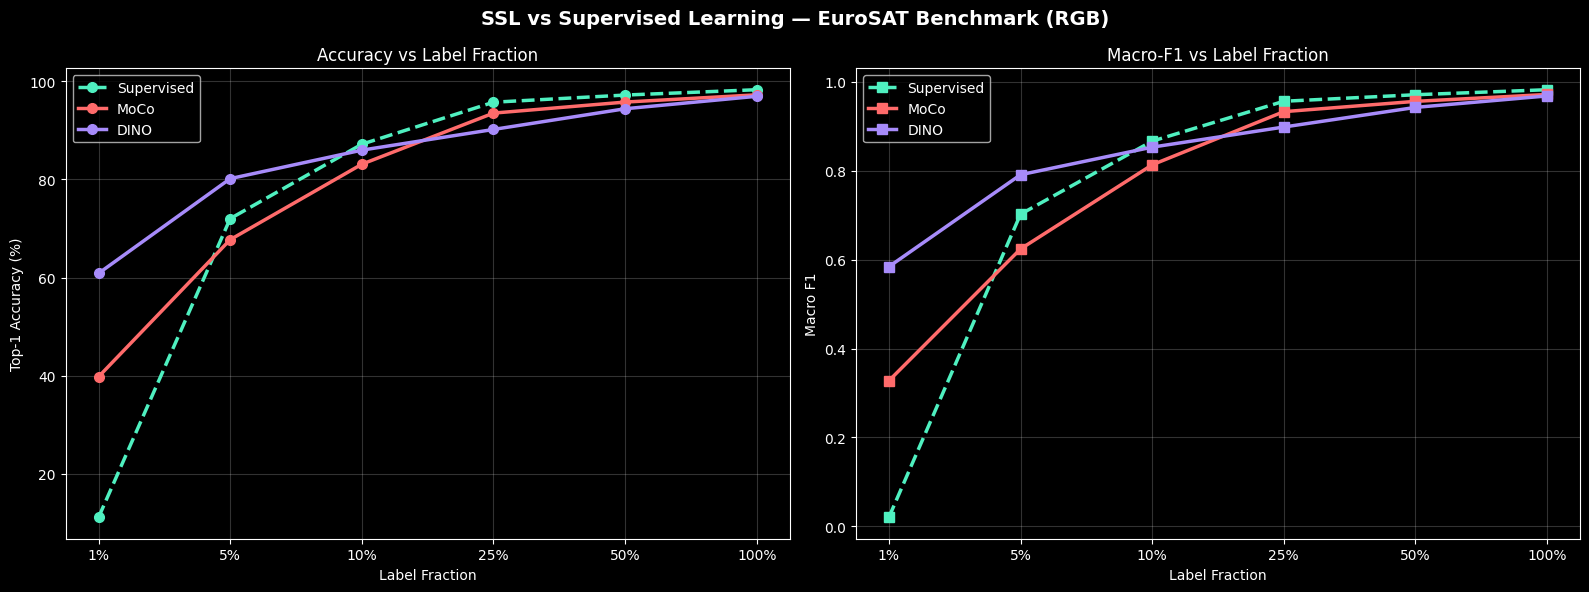

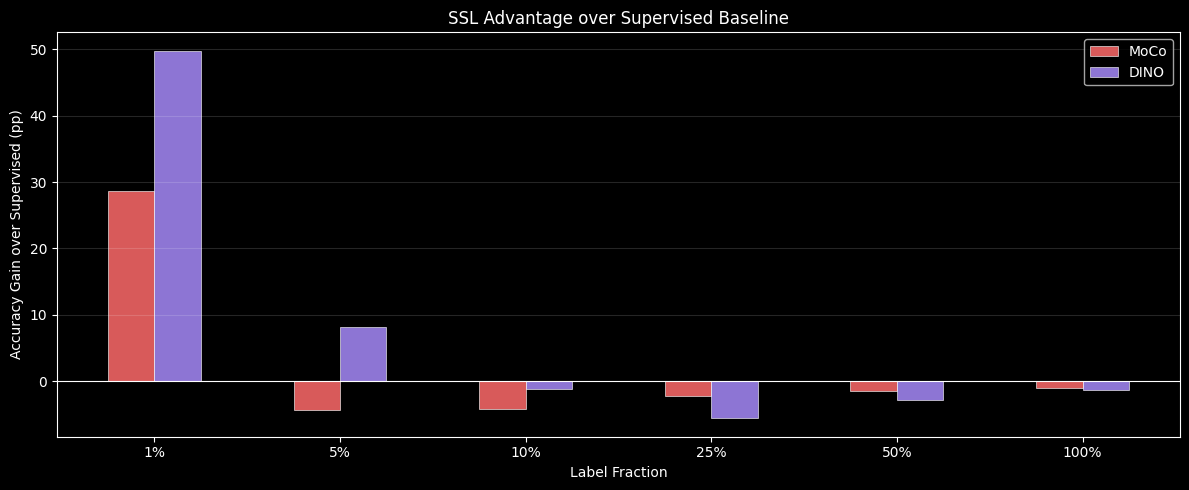


Crossover Analysis
MoCo      crossover:     1%   gain@1%: +28.7pp   gain@10%: +-4.1pp
DINO      crossover:     1%   gain@1%: +49.8pp   gain@10%: +-1.2pp


In [ ]:
# ── Load results from actual training runs ────────────────────────────────────
fracs    = LABEL_FRACTIONS
frac_pct = [f'{int(f*100)}%' for f in fracs]

RESULTS = {
    'Supervised': sup_df['accuracy'].tolist(),
    'MoCo':       moco_ft_df['accuracy'].tolist(),
    'DINO':       dino_ft_df['accuracy'].tolist()
}

MACRO_F1 = {
    'Supervised': sup_df['macro_f1'].tolist(),
    'MoCo':       moco_ft_df['macro_f1'].tolist(),
    'DINO':       dino_ft_df['macro_f1'].tolist()
}

COLORS = {'Supervised': '#4ff0c0', 'MoCo': '#ff6b6b', 'DINO': '#a78bfa'}
plt.style.use('dark_background')

# ── Figure 1: Accuracy + Macro-F1 curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'SSL vs Supervised Learning — EuroSAT Benchmark ({MODE.upper()})', fontsize=14, fontweight='bold')

for name, accs in RESULTS.items():
    ls = '--' if name == 'Supervised' else '-'
    axes[0].plot(frac_pct, [a*100 for a in accs], marker='o', linewidth=2.5,
                  linestyle=ls, color=COLORS[name], label=name, markersize=7)
axes[0].set_xlabel('Label Fraction')
axes[0].set_ylabel('Top-1 Accuracy (%)')
axes[0].set_title('Accuracy vs Label Fraction')
axes[0].legend()
axes[0].grid(alpha=0.2)

for name, f1s in MACRO_F1.items():
    ls = '--' if name == 'Supervised' else '-'
    axes[1].plot(frac_pct, f1s, marker='s', linewidth=2.5, linestyle=ls,
                  color=COLORS[name], label=name, markersize=7)
axes[1].set_xlabel('Label Fraction')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro-F1 vs Label Fraction')
axes[1].legend()
axes[1].grid(alpha=0.2)


plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_{MODE}_accuracy_curves.png', dpi=150)
plt.show()

# ── Figure 2: Delta bars ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sup = np.array(RESULTS['Supervised'])
x, w = np.arange(len(fracs)), 0.25

for i, (name, color) in enumerate([('MoCo', COLORS['MoCo']),
                                     ('DINO',   COLORS['DINO']),
                                     ]):
    delta = (np.array(RESULTS[name]) - sup) * 100
    ax.bar(x + (i-0.5)*w, delta, width=w, color=color, alpha=0.85,
           label=name, edgecolor='white', linewidth=0.5)

ax.axhline(0, color='white', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(frac_pct)
ax.set_xlabel('Label Fraction')
ax.set_ylabel('Accuracy Gain over Supervised (pp)')
ax.set_title('SSL Advantage over Supervised Baseline')
ax.legend()
ax.grid(alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_{MODE}_delta_bars.png', dpi=150)
plt.show()

# ── Crossover detection ───────────────────────────────────────────────────────
def find_crossover(method_accs, sup_accs, fracs):
    for f, s, m in zip(fracs, sup_accs, method_accs):
        if m >= s:
            return f
    return None

print('\nCrossover Analysis')
print('=' * 50)
sup_accs = RESULTS['Supervised']
for method in ['MoCo', 'DINO']:
    co     = find_crossover(RESULTS[method], sup_accs, fracs)
    gain_1  = (RESULTS[method][0] - sup_accs[0]) * 100
    gain_10 = (RESULTS[method][2] - sup_accs[2]) * 100
    co_str  = f'{int(co*100)}%' if co else 'Never'
    print(f'{method:8s}  crossover: {co_str:>6}   '
          f'gain@1%: +{gain_1:.1f}pp   gain@10%: +{gain_10:.1f}pp')

## 11. Per-Class F1 Breakdown & Heatmaps

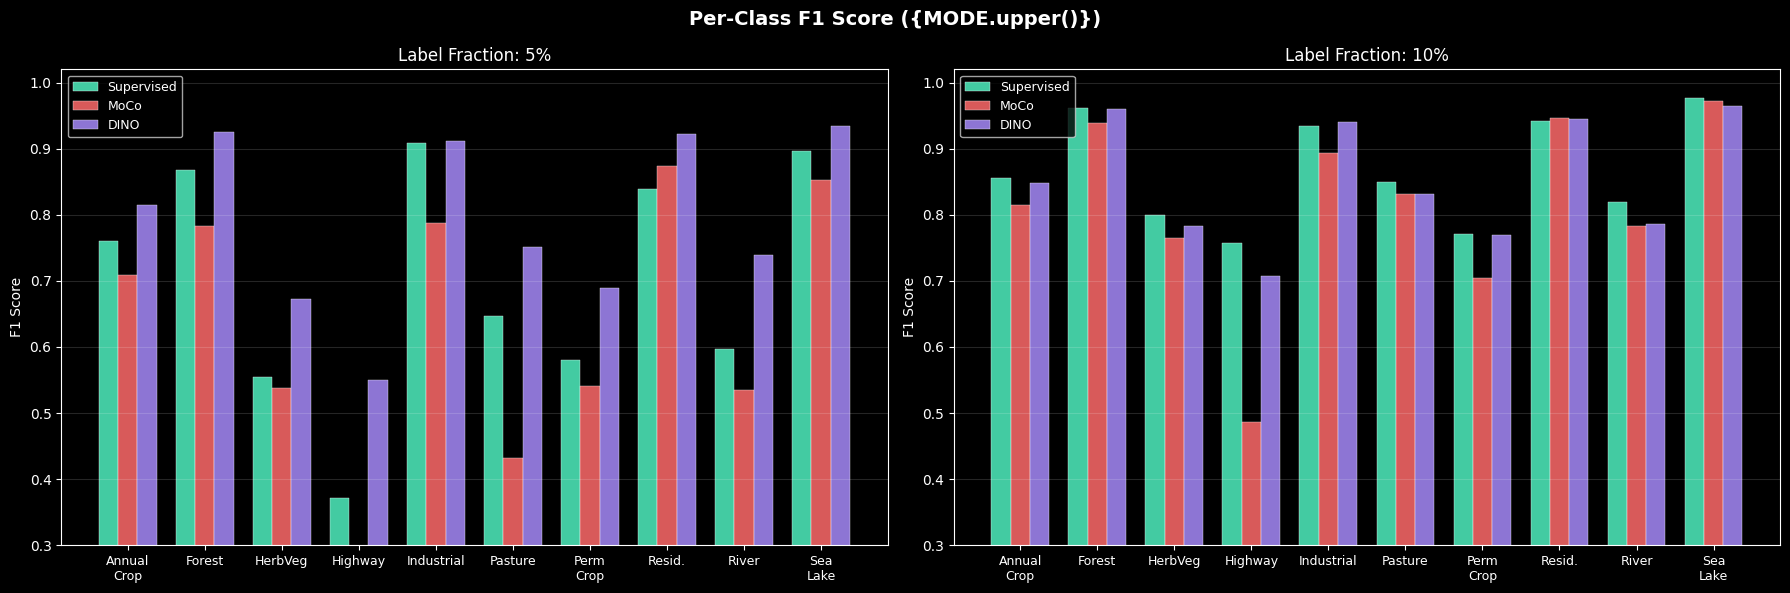

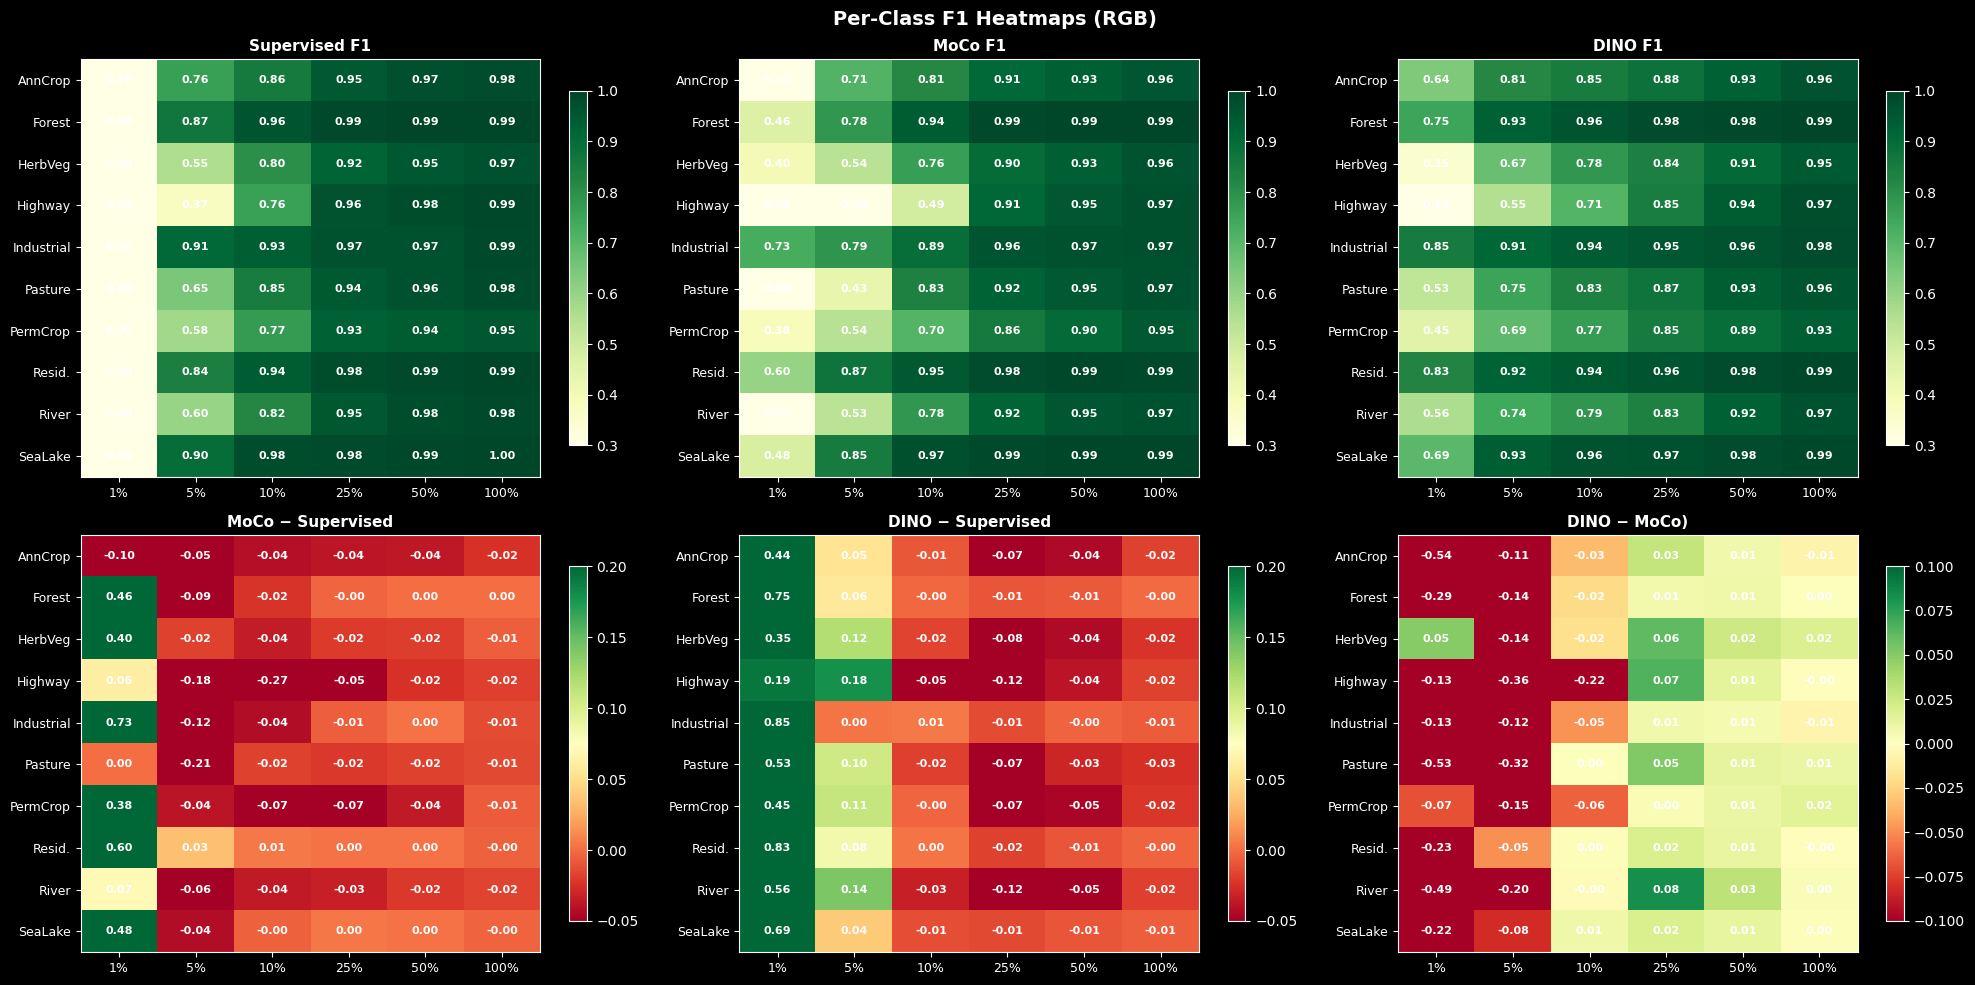

In [ ]:
# Build per-class F1 from actual results
def get_perclass_f1(df, fraction):
    row = df[df['fraction'] == fraction].iloc[0]
    return [row[f'f1_{cls}'] for cls in EUROSAT_CLASSES]

PER_CLASS_F1 = {
    '5%': {
        'Supervised': get_perclass_f1(sup_df,    0.05),
        'MoCo':     get_perclass_f1(moco_ft_df, 0.05),
        'DINO':       get_perclass_f1(dino_ft_df,   0.05),
    },
    '10%': {
        'Supervised': get_perclass_f1(sup_df,    0.10),
        'MoCo':     get_perclass_f1(moco_ft_df, 0.10),
        'DINO':       get_perclass_f1(dino_ft_df,   0.10),
    }
}

cls_labels = ['Annual\nCrop','Forest','HerbVeg','Highway','Industrial',
               'Pasture','Perm\nCrop','Resid.','River','Sea\nLake']

# ── Figure 3: Per-class grouped bars ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Per-Class F1 Score ({MODE.upper()})', fontsize=14, fontweight='bold')

for ax, frac_key, title in [(axes[0], '5%',  'Label Fraction: 5%'),
                              (axes[1], '10%', 'Label Fraction: 10%')]:
    x, w = np.arange(NUM_CLASSES), 0.25
    for i, (method, color) in enumerate(COLORS.items()):
        ax.bar(x + (i-1)*w, PER_CLASS_F1[frac_key][method], width=w,
               color=color, alpha=0.85, label=method, edgecolor='white', linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(cls_labels, fontsize=9)
    ax.set_ylabel('F1 Score')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_ylim(0.3, 1.02)
    ax.grid(alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_{MODE}_perclass_f1.png', dpi=150)
plt.show()

# ── Figure 4: F1 heatmaps ─────────────────────────────────────────────────────
def build_heatmap(df):
    """Build (n_classes x n_fractions) F1 array from a results dataframe."""
    matrix = []
    for cls in EUROSAT_CLASSES:
        row = []
        for frac in LABEL_FRACTIONS:
            val = df[df['fraction'] == frac].iloc[0][f'f1_{cls}']
            row.append(val)
        matrix.append(row)
    return np.array(matrix)

SUP_F1_HM  = build_heatmap(sup_df)
MOCO_F1_HM = build_heatmap(moco_ft_df)
DINO_F1_HM = build_heatmap(dino_ft_df)

DELTA_MOCO   = MOCO_F1_HM - SUP_F1_HM
DELTA_DINO = DINO_F1_HM - SUP_F1_HM

row_labels = ['AnnCrop','Forest','HerbVeg','Highway','Industrial',
               'Pasture','PermCrop','Resid.','River','SeaLake']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
plots = [
    (SUP_F1_HM,  'Supervised F1',         'YlGn',   0.3,   1.0),
    (MOCO_F1_HM, 'MoCo F1',               'YlGn',   0.3,   1.0),
    (DINO_F1_HM, 'DINO F1',               'YlGn',   0.3,   1.0),

    (DELTA_MOCO, 'MoCo − Supervised',     'RdYlGn', -0.05, 0.20),
    (DELTA_DINO, 'DINO − Supervised',     'RdYlGn', -0.05, 0.20),
    (DELTA_MOCO - DELTA_DINO, 'DINO − MoCo)', 'RdYlGn', -0.10, 0.10)
]
for ax, (data, title, cmap, vmin, vmax) in zip(axes.flatten(), plots):
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(frac_pct)))
    ax.set_xticklabels(frac_pct, fontsize=9)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.suptitle(f'Per-Class F1 Heatmaps ({MODE.upper()})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig4_{MODE}_heatmaps.png', dpi=150)
plt.show()

## 12. Summary & Conclusions

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = []
for method in ['MoCo', 'DINO']:
    co       = find_crossover(RESULTS[method], RESULTS['Supervised'], fracs)
    gain_1   = (RESULTS[method][0] - RESULTS['Supervised'][0]) * 100
    gain_10  = (RESULTS[method][2] - RESULTS['Supervised'][2]) * 100
    gain_100 = (RESULTS[method][-1] - RESULTS['Supervised'][-1]) * 100
    summary.append({
        'Mode':       MODE,
        'Method':      method,
        'Crossover':   f'{int(co*100)}%' if co else 'Never',
        'Gain @ 1%':   f'+{gain_1:.1f}pp',
        'Gain @ 10%':  f'+{gain_10:.1f}pp',
        'Gain @ 100%': f'+{gain_100:.1f}pp',
        'Acc @ 100%':  f'{RESULTS[method][-1]*100:.1f}%'
    })

print('=' * 70)
print(f'FINAL SUMMARY ({MODE.upper()})')
print('=' * 70)
print(pd.DataFrame(summary).to_string(index=False))

# ── Dynamic findings ──────────────────────────────────────────────────────────
methods = ['MoCo', 'DINO']
best_method  = max(methods, key=lambda m: RESULTS[m][0])
best_gain_1  = (RESULTS[best_method][0] - RESULTS['Supervised'][0]) * 100
best_co      = find_crossover(RESULTS[best_method], RESULTS['Supervised'], fracs)

crossover_dict = {
    m: find_crossover(RESULTS[m], RESULTS['Supervised'], fracs)
    for m in methods
}
valid_crossovers = {m: c for m, c in crossover_dict.items() if c is not None}
if valid_crossovers:
  earliest_co = min(valid_crossovers, key=valid_crossovers.get)
  latest_co   = max(valid_crossovers, key=valid_crossovers.get)
else:
  earliest_co = latest_co = None

# Per-class delta at 5% from actual results
dino_5pct    = np.array(get_perclass_f1(dino_ft_df, 0.05))
sup_5pct     = np.array(get_perclass_f1(sup_df,  0.05))
delta_5pct   = dino_5pct - sup_5pct

best_cls_idx  = delta_5pct.argmax()
worst_cls_idx = delta_5pct.argmin()
best_cls      = EUROSAT_CLASSES[best_cls_idx]
worst_cls     = EUROSAT_CLASSES[worst_cls_idx]
best_cls_gain = delta_5pct[best_cls_idx] * 100
worst_cls_gain = delta_5pct[worst_cls_idx] * 100

gap_100      = {m: (RESULTS[m][-1] - RESULTS['Supervised'][-1]) * 100
                for m in methods}
max_gap_100  = max(gap_100, key=gap_100.get)

print('\nKEY FINDINGS')
print('-' * 70)
findings = [
    f'1. {best_method} provides the largest low-label advantage '
    f'(+{best_gain_1:.1f}pp at 1% labels), crossing the supervised baseline '
    f'at ~{int(best_co*100)}% labels.' if best_co else
    f'1. provides the best low-label performance '
    f'(+{best_gain_1:.1f}pp at 1% labels), but does not cross the supervised baseline.',

    f'2. The crossover behavior varies: ',
    f'{earliest_co} will cross the earliest and {latest_co} the latest' if earliest_co else 'No crossover found'
    '2. No method can consistently surpass supervised among all label fractions.',


    f'3. Largest per-class SSL benefit at 5% labels: {best_cls} '
    f'(+{best_cls_gain:.1f}pp). Smallest benefit: {worst_cls} '
    f'({worst_cls_gain:+.1f}pp).',

    f'4. At 100% labels, {max_gap_100} still leads supervised by '
    f'+{gap_100[max_gap_100]:.1f}pp, but gains diminish -'
    f'SSL is the most valuablebeyond ~25% labeled data.'
]
for f in findings:
    print(f'  {f}\n')




print(f'\nResults directory → {RESULTS_DIR}/')
print(f'Checkpoints  → {CKPT_DIR}/')

FINAL SUMMARY (RGB)
Mode Method Crossover Gain @ 1% Gain @ 10% Gain @ 100% Acc @ 100%
 rgb   MoCo        1%   +28.7pp    +-4.1pp     +-1.0pp      97.3%
 rgb   DINO        1%   +49.8pp    +-1.2pp     +-1.3pp      97.0%

KEY FINDINGS
----------------------------------------------------------------------
  1. DINO provides the largest low-label advantage (+49.8pp at 1% labels), crossing the supervised baseline at ~1% labels.

  2. The crossover behavior varies: 

  MoCo will cross the earliest and MoCo the latest

  3. Largest per-class SSL benefit at 5% labels: Highway (+17.8pp). Smallest benefit: Industrial (+0.3pp).

  4. At 100% labels, MoCo still leads supervised by +-1.0pp, but gains diminish -SSL is the most valuablebeyond ~25% labeled data.


Results directory → /content/drive/MyDrive/ssl_satellite/results/
Checkpoints  → /content/drive/MyDrive/ssl_satellite/checkpoints/
